In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install shapely

In [3]:
import json
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

from shapely import wkt

In [4]:
def create_mask_from_json(json_path, img_size=(1024,1024)):

    mask = np.zeros(img_size, dtype=np.uint8)

    with open(json_path, 'r') as f:
        data = json.load(f)

    polygons = data['features']['xy']

    for poly in polygons:

        polygon = wkt.loads(poly['wkt'])

        coords = np.array(
            polygon.exterior.coords,
            dtype=np.int32
        )

        cv2.fillPoly(mask, [coords], 255)

    return mask

In [5]:
image_dir = "/content/drive/MyDrive/train/images"
label_dir = "/content/drive/MyDrive/train/labels"

In [6]:
image_files = os.listdir(image_dir)

post_images = [
    f for f in image_files
    if "post_disaster" in f
]

print("Total Post Images:", len(post_images))

Total Post Images: 2801


In [7]:
post_images = post_images[:500]

In [8]:
images = []
masks = []

for file in post_images:

    img_path = os.path.join(image_dir, file)

    json_name = file.replace(".png", ".json")
    json_path = os.path.join(label_dir, json_name)

    if not os.path.exists(json_path):
        continue

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256,256))

    mask = create_mask_from_json(json_path)

    mask = cv2.resize(
        mask,
        (256,256),
        interpolation=cv2.INTER_NEAREST
    )

    images.append(img)
    masks.append(mask)

print("Images Loaded:", len(images))
print("Masks Loaded:", len(masks))

Images Loaded: 500
Masks Loaded: 500


In [9]:
images = np.array(images)

masks = np.array(masks)

print(images.shape)
print(masks.shape)

(500, 256, 256, 3)
(500, 256, 256)


In [10]:
images = images / 255.0

In [11]:
masks = (masks > 0).astype(np.float32)

print(np.unique(masks))

[0. 1.]


In [12]:
masks = np.expand_dims(
    masks,
    axis=-1
)

print(masks.shape)

(500, 256, 256, 1)


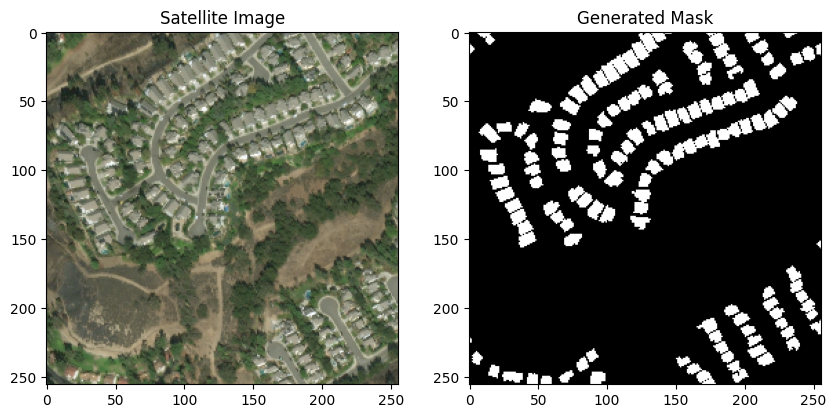

In [13]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(images[0])
plt.title("Satellite Image")

plt.subplot(1,2,2)
plt.imshow(masks[0].squeeze(), cmap='gray')
plt.title("Generated Mask")

plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(400, 256, 256, 3)
(100, 256, 256, 3)


In [15]:
import tensorflow as tf

from tensorflow.keras import layers, Model

In [16]:
inputs = layers.Input((256,256,3))

# Encoder
c1 = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
p1 = layers.MaxPooling2D()(c1)

c2 = layers.Conv2D(64,3,activation='relu',padding='same')(p1)
p2 = layers.MaxPooling2D()(c2)

# Bottleneck
b1 = layers.Conv2D(128,3,activation='relu',padding='same')(p2)

# Decoder
u1 = layers.UpSampling2D()(b1)
c3 = layers.Conv2D(64,3,activation='relu',padding='same')(u1)

u2 = layers.UpSampling2D()(c3)
c4 = layers.Conv2D(32,3,activation='relu',padding='same')(u2)

outputs = layers.Conv2D(1,1,activation='sigmoid')(c4)

model = Model(inputs, outputs)

In [17]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=15,
    batch_size=8
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 136ms/step - accuracy: 0.9605 - loss: 0.2598 - val_accuracy: 0.9870 - val_loss: 0.0912
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9793 - loss: 0.1187 - val_accuracy: 0.9870 - val_loss: 0.0861
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9793 - loss: 0.0956 - val_accuracy: 0.9870 - val_loss: 0.0679
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9793 - loss: 0.0776 - val_accuracy: 0.9870 - val_loss: 0.0459
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9793 - loss: 0.0708 - val_accuracy: 0.9870 - val_loss: 0.0446
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9793 - loss: 0.0596 - val_accuracy: 0.9870 - val_loss: 0.0445
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9793 - loss: 0.0619 - val_accuracy: 0.9870 - val_loss: 0.0439
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9798 - loss: 0.0569 - val_accuracy: 0.9869 -

In [19]:
pred = model.predict(X_test[:3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


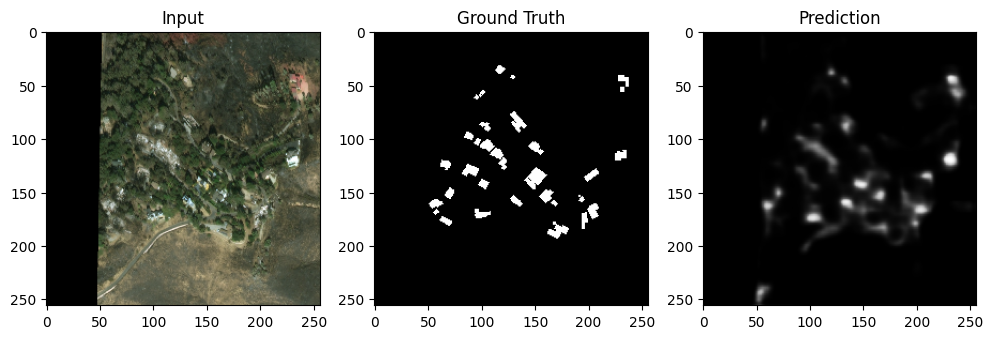

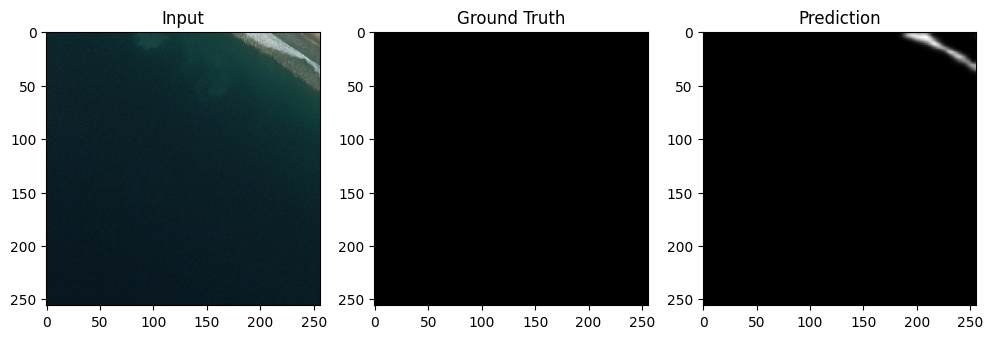

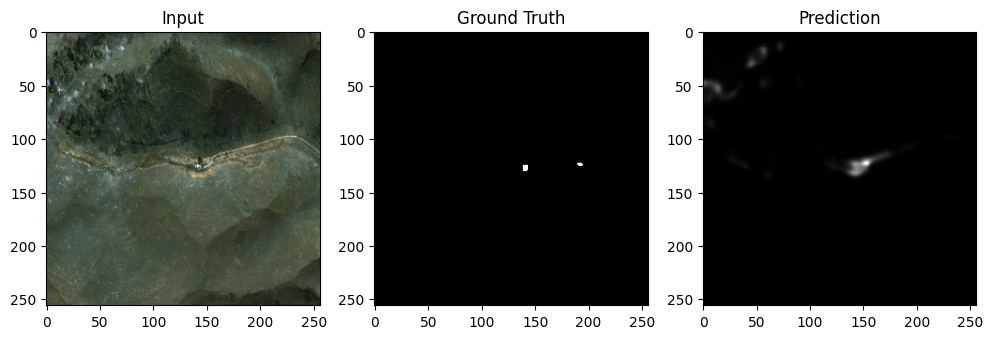

In [20]:
for i in range(3):

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(X_test[i])
    plt.title("Input")

    plt.subplot(1,3,2)
    plt.imshow(y_test[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")

    plt.subplot(1,3,3)
    plt.imshow(pred[i].squeeze(), cmap='gray')
    plt.title("Prediction")

    plt.show()

In [21]:
def dice_score(y_true, y_pred):

    y_pred = (y_pred > 0.5).astype(np.float32)

    intersection = np.sum(y_true * y_pred)

    return (
        2.0 * intersection + 1e-7
    ) / (
        np.sum(y_true)
        + np.sum(y_pred)
        + 1e-7
    )

In [22]:
pred_all = model.predict(X_test)

score = dice_score(y_test, pred_all)

print("Dice Score:", score)

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step
Dice Score: 0.3396657


In [23]:
def iou_score(y_true, y_pred):

    y_pred = (y_pred > 0.5).astype(np.float32)

    intersection = np.sum(y_true * y_pred)

    union = (
        np.sum(y_true)
        + np.sum(y_pred)
        - intersection
    )

    return (intersection + 1e-7) / (union + 1e-7)

pred_all = model.predict(X_test)

print("IoU:", iou_score(y_test, pred_all))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
IoU: 0.2045767


In [24]:
model.save("disaster_segmentation_unet.h5")